# PROJECT EDA


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [9]:
dt=pd.read_csv("../data/placement.csv")
dt.head(10)

,student_id,student_name,course,company,role,package(Rs.L),offer_date,status,placement_officer,Unnamed: 9
0,STU0001,Kiran,MERN Stack Development,NaN,NaN,NaN,NaN,Not Placed,NaN,NaN
1,STU0002,Tanya,Data Science with Python,Accenture,Software Engineer,18.8,3/27/2026,In Progress,Nivetha S,NaN
2,STU0003,Faisal,Data Science with Python,Infosys,System Engineer,6.9,3/24/2026,Placed,Nivetha S,NaN
3,STU0004,Ajay,Python Full Stack Development,Google,QA Engineer,4.3,3/20/2026,Placed,Nivetha S,NaN
4,STU0005,Rahul,MERN Stack Development,NaN,NaN,NaN,NaN,Not Placed,NaN,NaN
5,STU0006,Arjun,DevOps,Infosys,AI Engineer,17.7,3/19/2026,Placed,Nivetha S,NaN
6,STU0007,Irfan,React Frontend Developer,TCS,Software Engineer,14.4,3/16/2026,In Progress,Nivetha S,NaN
7,STU0008,Neeraj,Python Full Stack Development,Accenture,Cloud Engineer,13.0,3/10/2026,In Progress,Nivetha S,NaN
8,STU0009,Anjali,Business Analytics,NaN,NaN,NaN,NaN,Not Placed,NaN,NaN
9,STU0010,Neeraj,MERN Stack Development,NaN,NaN,NaN,NaN,Not Placed,NaN,NaN


### KPI

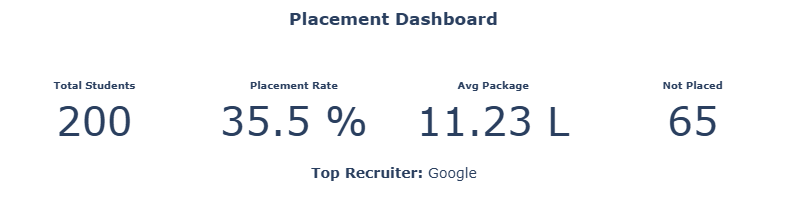

In [24]:

# ── Clean columns ──
dt.columns = dt.columns.str.strip().str.lower()
dt['status'] = dt['status'].str.strip()

# ── Compute KPIs ──
total_students    = len(dt)
placed_count      = (dt['status'] == 'Placed').sum()
not_placed_count  = (dt['status'] == 'Not Placed').sum()
placement_rate    = round(placed_count / total_students * 100, 1) if total_students else 0
avg_package       = round(dt['package(rs.l)'].dropna().mean(), 2)

# ✅ FIX: define top_company
top_company = dt.loc[dt['company'].notna(), 'company'].value_counts().idxmax()

# ── Figure ──
fig = go.Figure()

# Helper
def add_kpi(value, title, x_pos, suffix=""):
    fig.add_trace(go.Indicator(
        mode="number",
        value=value,
        title={"text": f"<b>{title}</b>"},
        number={
            "font": {"size": 40},
            "suffix": suffix
        },
        domain={'x': x_pos, 'y': [0, 1]}
    ))

# ── KPIs ──
add_kpi(total_students,   "Total Students",   [0.00, 0.22])
add_kpi(placement_rate,   "Placement Rate",   [0.26, 0.48], " %")
add_kpi(avg_package,      "Avg Package",      [0.52, 0.74], " L")
add_kpi(not_placed_count, "Not Placed",       [0.78, 1.00])

# ── Top Recruiter (clean position) ──
fig.add_annotation(
    x=0.5, y=0.05,   # ✅ FIXED POSITION
    text=f"<b>Top Recruiter:</b> {top_company}",
    showarrow=False,
    xref="paper", yref="paper",
    font=dict(size=14),
    align="center"
)

# ── Layout ──
fig.update_layout(
    title_text="<b>Placement Dashboard</b>",
    title_x=0.5,
    height=220,
    margin=dict(t=50, b=30, l=10, r=10),  # more bottom space
    template="plotly_white"
)

fig.show()

In [ ]:
avg_pkg = dt[dt['Package (Rs.L)'].notna()].groupby('Course')['Package (Rs.L)'].mean().reset_index()
fig = px.area(avg_pkg, x='Course', y='Package (Rs.L)', title='Avg Package by Course (Area)', markers=True)
fig.update_layout(xaxis_tickangle=-40)
fig.show()

In [ ]:
COLOR_MAP = {'Placed': '#1D9E75', 'Not Placed': '#D85A30', 'In Progress': '#EF9F27'}

fig = px.treemap(
    dt,
    path=[px.Constant('All'), 'Course', 'Status'],
    title='<b>Course → Placement Status Breakdown</b>',
    color='Status',
    color_discrete_map=COLOR_MAP
)
fig.update_layout(
    title_font_size=18,
    margin=dict(t=50, l=10, r=10, b=10),
    paper_bgcolor='white'
)
fig.update_traces(textinfo="label+value+percent root")
fig.show()

In [ ]:
# Course → Company → Role (only placed students)
df_chart1 = dt[dt['Company'].notna() & dt['Role'].notna()].copy()

fig1 = px.sunburst(
    df_chart1,
    path=['Course', 'Company', 'Role'],
    title='<b>Course → Company → Role</b>',
    color='Course',
    color_discrete_sequence=px.colors.qualitative.Plotly
)
fig1.update_traces(
    textinfo='label+percent parent',
    insidetextorientation='radial'
)
fig1.update_layout(
    title_font_size=18,
    paper_bgcolor='white',
    margin=dict(t=60, b=20, l=20, r=20),
    height=600
)
fig1.show()

In [ ]:
avg_pkg = (
    dt[dt['Package (Rs.L)'].notna()]
    .groupby('Course')['Package (Rs.L)']
    .agg(['mean', 'min', 'max', 'count'])
    .reset_index()
    .rename(columns={'mean': 'Avg Package', 'min': 'Min', 'max': 'Max', 'count': 'Students Placed'})
    .sort_values('Avg Package', ascending=False)
)

fig = px.bar(
    avg_pkg,
    x='Course',
    y='Avg Package',
    text='Avg Package',
    color='Avg Package',
    color_continuous_scale='Teal',
    hover_data={'Min': True, 'Max': True, 'Students Placed': True},
    title='<b>Average Package by Course (Rs. Lakhs)</b>'
)
fig.update_traces(texttemplate='₹%{text:.1f}L', textposition='outside')
fig.update_layout(
    xaxis_tickangle=-40,
    title_font_size=18,
    coloraxis_showscale=True,
    paper_bgcolor='white',
    plot_bgcolor='#f8f9fa',
    yaxis_title='Avg Package (Rs. Lakhs)',
    margin=dict(t=50, b=100)
)
fig.show()

In [ ]:
status_course = (
    dt.groupby(['Course', 'Status'])
    .size()
    .reset_index(name='Count')
)
total_course = dt.groupby('Course').size().reset_index(name='Total')
status_course = status_course.merge(total_course, on='Course')
status_course['Percentage'] = (status_course['Count'] / status_course['Total'] * 100).round(1)

fig = px.bar(
    status_course,
    x='Course',
    y='Percentage',
    color='Status',
    barmode='group',
    text='Percentage',
    color_discrete_map=COLOR_MAP,
    title='<b>Placement Rate by Course (%)</b>'
)
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(
    xaxis_tickangle=-35,
    title_font_size=18,
    paper_bgcolor='white',
    plot_bgcolor='#f8f9fa',
    yaxis_title='Percentage of Students (%)',
    legend_title='Status',
    margin=dict(t=60, b=80)
)
fig.show()

In [ ]:
company_hiring = (
    dt[dt['Company'].notna()]
    .groupby('Company')
    .size()
    .reset_index(name='Hired Count')
    .sort_values('Hired Count', ascending=True)
)

fig = px.bar(
    company_hiring,
    x='Hired Count',
    y='Company',
    orientation='h',
    text='Hired Count',
    color='Hired Count',
    color_continuous_scale='Blues',
    title='<b>Company-wise Hiring Count</b>'
)
fig.update_traces(textposition='outside')
fig.update_layout(
    title_font_size=18,
    coloraxis_showscale=False,
    paper_bgcolor='white',
    plot_bgcolor='#f8f9fa',
    xaxis_title='Number of Students Hired',
    margin=dict(t=60, r=60)
)
fig.show()

In [ ]:
status_counts = dt['Status'].value_counts().reset_index()
status_counts.columns = ['Status', 'Count']

fig = go.Figure(go.Pie(
    labels=status_counts['Status'],
    values=status_counts['Count'],
    hole=0.55,
    marker=dict(colors=[COLOR_MAP.get(s, '#999') for s in status_counts['Status']]),
    textinfo='label+percent',
    textfont_size=13,
    pull=[0.05 if s == 'Placed' else 0 for s in status_counts['Status']]
))

total = status_counts['Count'].sum()
fig.update_layout(
    title='<b>Overall Placement Outcome</b>',
    title_font_size=18,
    paper_bgcolor='white',
    annotations=[dict(text=f'<b>{total}<br>Students</b>', x=0.5, y=0.5,
                      font_size=16, showarrow=False)],
    legend=dict(orientation='h', y=-0.1),
    margin=dict(t=60, b=60)
)
fig.show()

In [ ]:
company_pkg = (
    dt[dt['Package (Rs.L)'].notna()]
    .groupby('Company')
    .agg(
        Avg_Package=('Package (Rs.L)', 'mean'),
        Total_Hired=('Package (Rs.L)', 'count'),
        Max_Package=('Package (Rs.L)', 'max')
    )
    .reset_index()
)

fig = px.scatter(
    company_pkg,
    x='Total_Hired',
    y='Avg_Package',
    text='Company',
    size='Max_Package',
    color='Avg_Package',
    color_continuous_scale='RdYlGn',
    trendline='ols',           # shows if hiring more = paying more
    hover_data={'Max_Package': True, 'Total_Hired': True},
    title='<b>Do Companies That Hire More Pay Better? (Trend Line)</b>',
    size_max=35
)
fig.update_traces(textposition='top center', selector=dict(mode='markers+text'))
fig.update_layout(
    title_font_size=16,
    paper_bgcolor='white',
    plot_bgcolor='#f8f9fa',
    xaxis_title='Total Students Hired',
    yaxis_title='Avg Package (Rs. Lakhs)',
    coloraxis_showscale=False,
    margin=dict(t=70, b=40)
)
fig.show()